<a href="https://colab.research.google.com/github/Fauzi455/PCVK26_12_M-Fauzi-R/blob/main/Week6_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#D. PRAKTIKUM FILTER

In [1]:
NAMA = 'Mohamat Fauzi Rohman'
NIM = '244107020067' # ganti dengan NIM sendiri
print(NAMA, NIM)

Mohamat Fauzi Rohman 244107020067


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

Buatlah fungsi konvolusi. Catatan: parameter yang digunakan boleh dimodifikasi.
Misal, hanya menggunakan parameter image dan kernel saja, atau image, kernel, dan
padding.

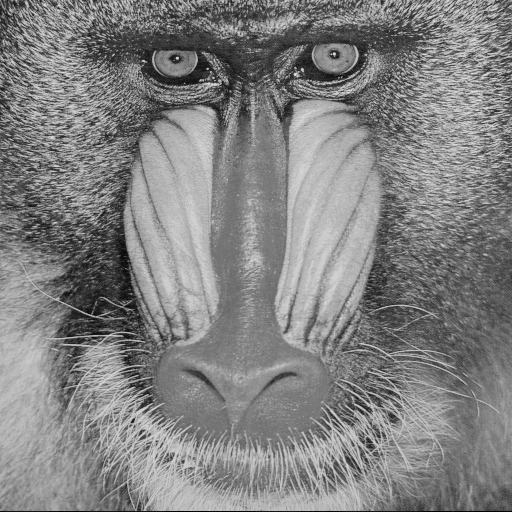

In [12]:
import numpy as np

def convolution2d(image, kernel, stride, padding):
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    if padding > 0:
        padded_img = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    else:
        padded_img = image.copy()
    pad_h, pad_w = padded_img.shape

    #menghitung dimensi matriks output
    out_h = int(((pad_h - k_h) / stride) + 1)
    out_w = int(((pad_w - k_w) / stride) + 1)

    output = np.zeros((out_h, out_w), dtype=np.float32)

    #proses konvolusi bergeser
    for y in range(0, out_h):
        for x in range(0, out_w):
            y_start = y * stride
            y_end = y_start + k_h
            x_start = x * stride
            x_end = x_start + k_w

            #mengekstrak jendela area citra sesuai ukuran kernel
            region = padded_img[y_start:y_end, x_start:x_end]

            #perkalian elemen per elemen dan jumlahkan
            val = np.sum(region * kernel)
            output[y, x] = val

    #normalisasi/clipping nilai intensitas piksel ke rentang [0, 255]
    output = np.clip(output, 0, 255).astype(np.uint8)
    return output

img_path = '/content/drive/MyDrive/PCVK/Images/244107020067/mandrill.tiff'
img = cv.imread(img_path)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

kernel_sharpen = np.array([
    [0, -1,  0],
    [-1, 5, -1],
    [0, -1,  0]
], dtype=np.float32)

convolution2d(img_gray, kernel_sharpen, 1, 2)
cv2_imshow(img_gray)

Buat Image Filter untuk Average filter, low pass filter, high pass filter, dan beberapa filter
berikut:

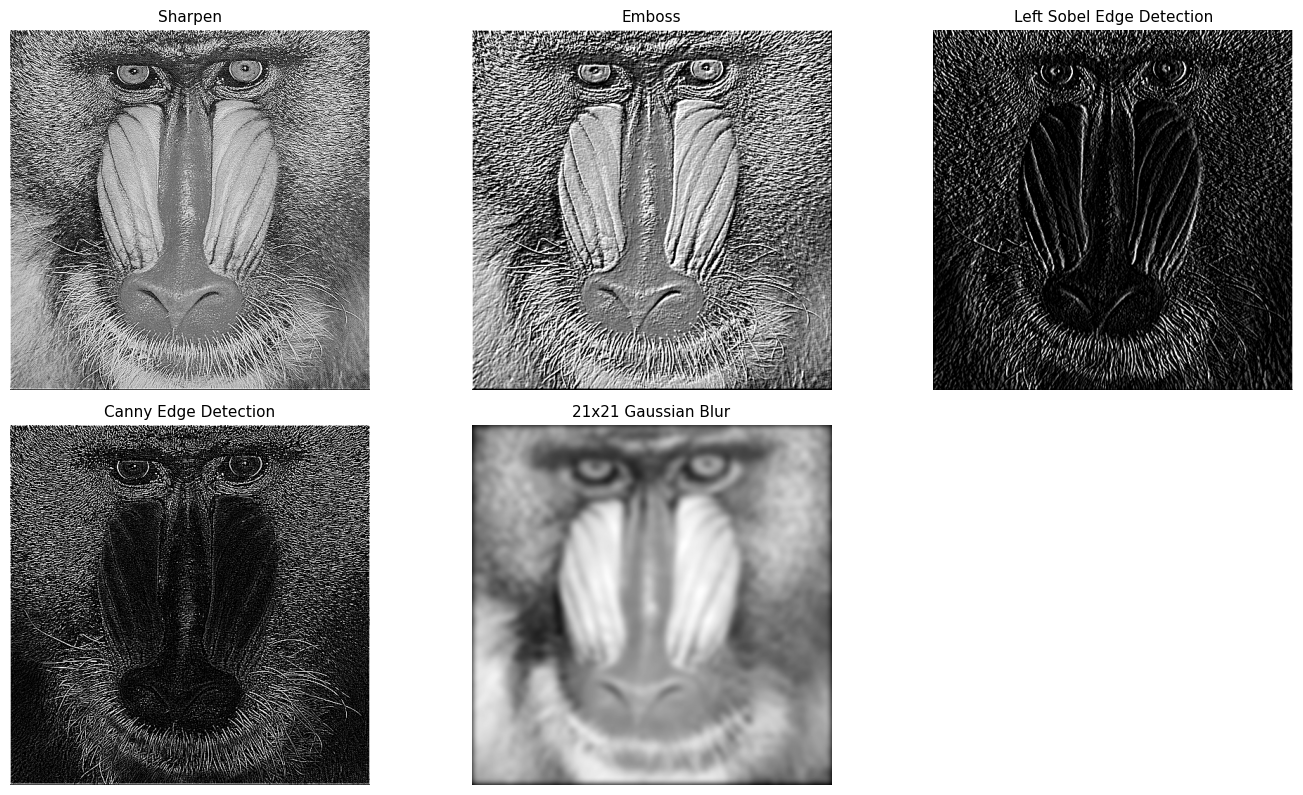

In [15]:
# 1. Definisi Kernel
kernel_average = np.ones((3, 3), dtype=np.float32) / 9.0
res_average = convolution2d(img_gray, kernel_average, stride=1, padding=1)

kernel_lpf = (
    np.array([[1, 1, 1], [1, 4, 1], [1, 1, 1]], dtype=np.float32) / 12.0)
res_lpf = convolution2d(img_gray, kernel_lpf, stride=1, padding=1)

kernel_hpf = np.array(
    [[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float32)
res_hpf = convolution2d(img_gray, kernel_hpf, stride=1, padding=1)

kernel_sharpen = np.array(
    [[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
res_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)

kernel_emboss = np.array(
    [[-2, -1, 0], [-1, 1, 1], [0, 1, 2]], dtype=np.float32)
res_emboss = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)

kernel_left_sobel = np.array(
    [[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)
res_left_sobel = convolution2d(
    img_gray, kernel_left_sobel, stride=1, padding=1)

# Kernel Laplacian / Deteksi Tepi Omnidirectional
kernel_laplacian = np.array(
    [[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float32)
res_laplacian = convolution2d(img_gray, kernel_laplacian, stride=1, padding=1)

kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel_21 = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()
res_gaussian_21 = convolution2d(
    img_gray, gauss_kernel_21, stride=1, padding=kernel_size // 2)

# 2. Menampilkan Semua Hasil dalam Subplot Grid (3 Baris x 3 Kolom)
images = [
    (res_sharpen, "Sharpen"),
    (res_emboss, "Emboss"),
    (res_left_sobel, "Left Sobel Edge Detection"),
    (res_canny_mask, "Canny Edge Detection"),
    (res_gaussian_21, "21x21 Gaussian Blur"),
]

plt.figure(figsize=(14, 12))

for i, (img, title) in enumerate(images):
    plt.subplot(3, 3, i + 1)
    # Gunakan np.clip atau biarkan matplotlib memetakan rentang nilai secara otomatis
    plt.imshow(img, cmap="gray")
    plt.title(title, fontsize=11)
    plt.axis("off")

plt.tight_layout()
plt.show()

#E. FILTER LIBRARY DAN FILTER MODERN

Percobaan 1:
Pada percobaan 1 ini, kita akan membuat Filter Gaussian, Sharpen, dan Canny menggunakan library
filter2d dari OpenCV. Filter ini akan kita terapkan pada Image RGB. Pada bagian awal kode terdapat
fungsi show_side_by_side yang digunakan untuk menampilkan gambar secara berdampingan.

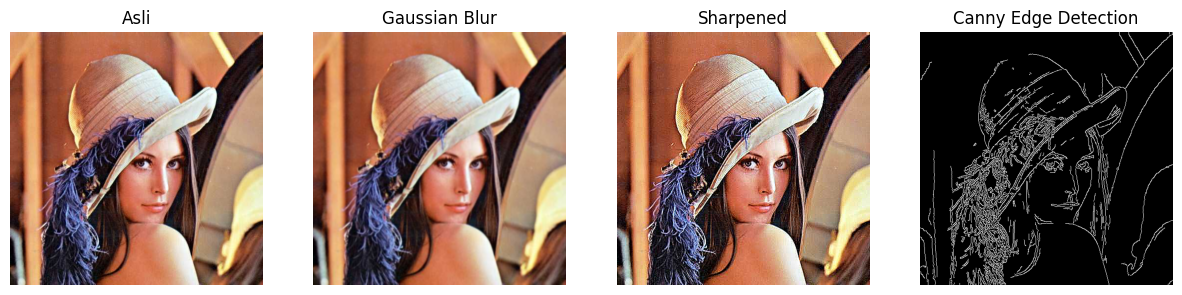

In [17]:
#fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap="gray")
        else:  # color BGR -> RGB
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/PCVK/Images/244107020067/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(img_gray, 100, 200)
sharpen_kernel = np.array([
    [0, -1,  0],
    [-1, 5, -1],
    [0, -1,  0]
], dtype=np.float32)
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side(
    [img, blur, sharpened, edges],
    ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"]
)

Percobaan 2:
Pada percobaan 2 berikut ini akan dilakukan filtering modern dari Library OpenCV. Dua filter yang akan
digunakan adalah Bilateral Filtering dan Guided Filter.

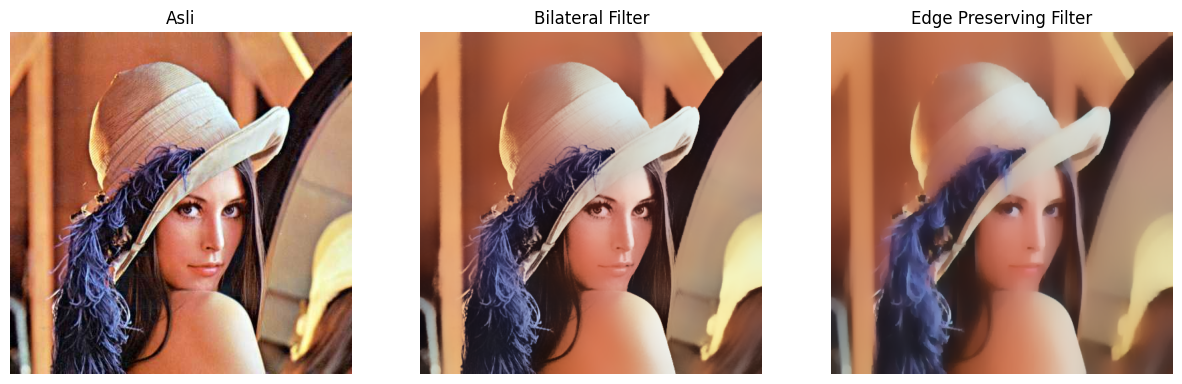

In [18]:
#filter modern dari openCV
#Bilateral Filter
bilateral = cv.bilateralFilter(img, 50, 100, 100)

#Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side(
    [img, bilateral, edge_preserve],
    ["Asli", "Bilateral Filter", "Edge Preserving Filter"]
)

Percobaan 3:
Percobaan kali ini akan mencoba melihat proses Filtering pada CNN (bagian Feature Map), lakukan
running code beberapa kali dan perhatikan hasil outputnya. Apa yang dapat kamu simpulkan dari hasil
keluaran tersebut.

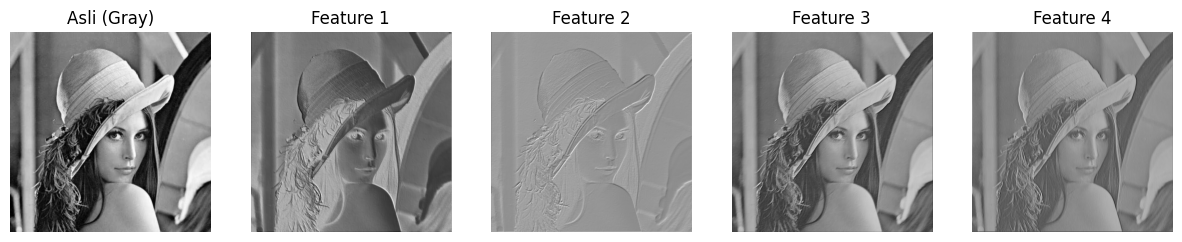

In [20]:
#filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

#ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

#hasil CNN
with torch.no_grad():
    features = model(img_tensor)

#visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

Percobaan 4:
Percobaan kali ini akan melakukan efek Beauty dan Vintage yang biasanya digunakan pada Aplikasi
popular saat ini. Filter yang digunakan merupakan kombinasi dari filter tradisional. Perlu diketahui
untuk filter aplikasi popular bisa jadi tidak menggunakan metode yang sama. Pada Aplikasi popular
bisa jadi menggunakan model GenAI dengan data Training untuk memberikan hasil yang lebih akurat.

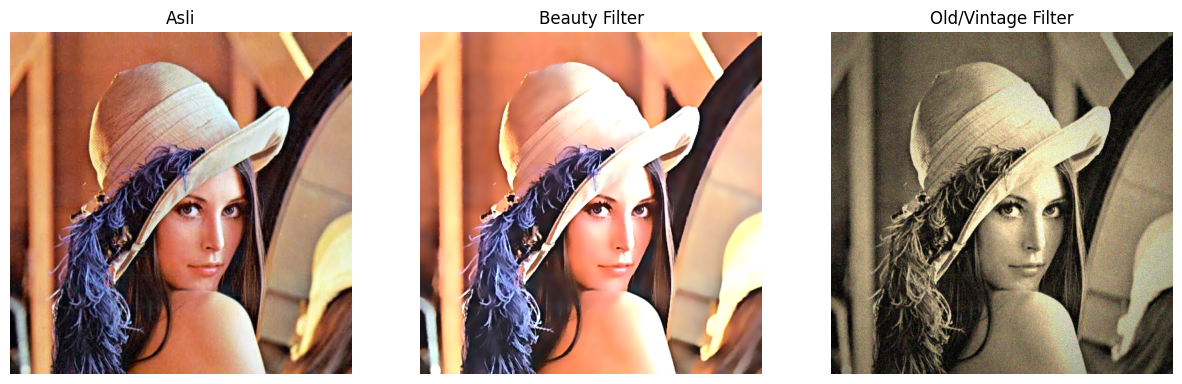

In [23]:
#Beauty Filter
#step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

#step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

#step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)


#Old/Vintage Filter
#step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

#step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

#step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side(
    [img, beauty, old_img],
    ["Asli", "Beauty Filter", "Old/Vintage Filter"]
)

Percobaan 5: akan menunjukkan pada anda filter anime / cartoon menggunakan kombinasi filter
tradisional.

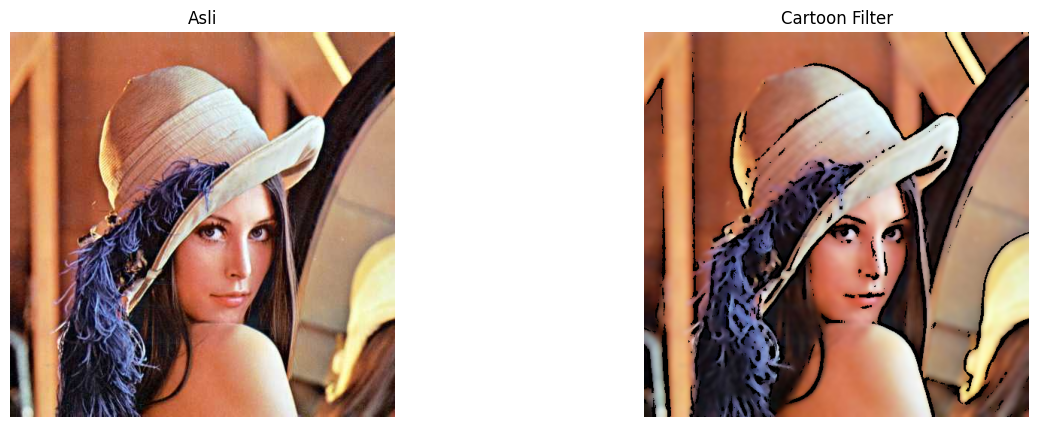

In [24]:
#filter anime/cartoon
#step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

#step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

#step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

#tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

Percobaan 6:
Pada Percobaan 6 akan ditunjukkan contoh Filter Malam.

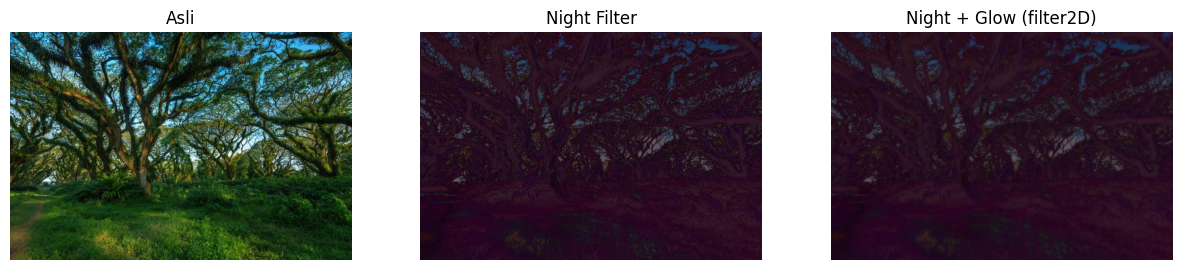

In [25]:
#night filter
img = cv.imread("/content/drive/MyDrive/PCVK/Images/244107020067/djawatan.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

#step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

#step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

#kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

Percobaan 7: menunjukkan Filter Pagi dan Pagi ditambahkan efek kabut.

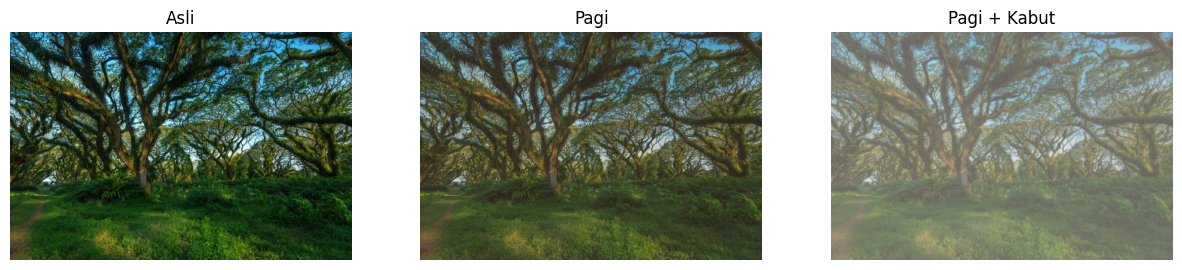

In [26]:
#filter suasana pagi dan Kabut
#step 1: Kurangi kontras & cerahkan
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

#step 2: Tambahkan warm tone (kemerahan / oranye)
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

#step 3: Tambahkan haze (kabut tipis) dengan filter2D
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

#tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

#Tugas Praktikum

1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and Pepper”

    a. Tambahkan noise bintik hitam-putih (Salt and Pepper) ke sebuah citra keabuan (grayscale).

    b. Terapkan Mean Filter(3 x 3) dan Median Filter (3 x 3).
    
    c. Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus noise tersebut dibanding Mean Filter.

2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)

    a. Buat kernel penajaman (Sharpening Kernel) ukuran 3 x 3 dan 5 x 5.

    b. Terapkan pada citra yang sedikit buram (blurry).

    c. Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.

3. Tugas Kreasi: Filter Kartun Sederhana

    a. Buatlah sebuah fungsi kustom bernama kartun(image) yang menggabungkan:
      * Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata.
      * Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.
      * Penggabungan (kombinasi) keduanya menggunakan operasi logika/perkalian piksel.
      
    b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan.